In [1]:
import torch
import pandas as pd
from tqdm import tqdm

In [2]:
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

# Back translation (en -> de -> en)
translator_en_de = pipeline("translation", model="Helsinki-NLP/opus-mt-en-de")
translator_de_en = pipeline("translation", model="Helsinki-NLP/opus-mt-de-en")

# Paraphraser (T5)
paraphraser = pipeline("text2text-generation", model="Vamsi/T5_Paraphrase_Paws")

c:\Users\reese\Documents\SUTD stuff\work stuff\term 6\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\reese\Documents\SUTD stuff\work stuff\term 6\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as ex

In [24]:
from transformers import pipeline

style_model = pipeline("text2text-generation", model="google/flan-t5-large")

c:\Users\reese\Documents\SUTD stuff\work stuff\term 6\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\reese\Documents\SUTD stuff\work stuff\term 6\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\reese\.cache\huggingface\hub\models--google--flan-t5-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to ac

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
def back_translate(text):
    try:
        de = translator_en_de(text)[0]['translation_text']
        en = translator_de_en(de)[0]['translation_text']
        return en
    except:
        return text

In [ ]:
def paraphrase(text, num_return_sequences=2):
    try:
        outputs = paraphraser(
            text,
            max_length=128,
            num_return_sequences=num_return_sequences,
            do_sample=True,
            top_k=50,
            top_p=0.95
        )
        return [o['generated_text'] for o in outputs]
    except:
        return [text] * num_return_sequences

In [6]:
import random

def add_noise(text, prob=0.1):
    chars = list(text)
    for i in range(1, len(chars)):
        if random.random() < prob:
            chars[i], chars[i-1] = chars[i-1], chars[i]
    return "".join(chars)

In [33]:
def rewrite_to_human(text):
    prompt = f"While keeping the meaning the same, rewrite this to sound casual and human: {text}"
    return style_model(prompt)[0]['generated_text']

def rewrite_to_ai(text):
    prompt = f"While keeping the meaning the same, rewrite this to sound like it was written by AI: {text}"
    return style_model(prompt)[0]['generated_text']

In [7]:
import pandas as pd
df = pd.read_csv("../cleaned_data/final_merged.csv")
rawtext = df["full_post_clean"].values
labels = df["Label"].values
print(type(rawtext))
print(type(labels))

<class 'pandas.arrays.ArrowStringArray'>
<class 'numpy.ndarray'>


In [8]:
# get subset from full dataset

import random

N = 1000
indices = random.sample(range(len(rawtext)), N)

sample_texts = [rawtext[i] for i in indices]
sample_labels = [labels[i] for i in indices]

print(type(sample_texts))

<class 'list'>


In [9]:
# create adversarial texts

bt_texts = []
para1_texts = []
para2_texts = []
noise_texts = []

for text in tqdm(sample_texts):
    # Back-translation
    bt = back_translate(text)
    bt_texts.append(bt)

    # Paraphrases
    paras = paraphrase(text, 2)
    para1_texts.append(paras[0])
    para2_texts.append(paras[1])
    

    # Noise
    noise = add_noise(text)
    noise_texts.append(noise)

  2%|▏         | 22/1000 [06:16<5:06:32, 18.81s/it]Token indices sequence length is longer than the specified maximum sequence length for this model (782 > 512). Running this sequence through the model will result in indexing errors
Your input_length: 782 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Token indices sequence length is longer than the specified maximum sequence length for this model (828 > 512). Running this sequence through the model will result in indexing errors
 89%|████████▉ | 893/1000 [2:45:16<19:24, 10.88s/it]Your input_length: 501 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 511 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
100%|██████████| 1000/1000 [3:06:54<00:00, 11.21s/it]


In [34]:
# create adversarial texts for style

style_texts = []

for idx in tqdm(range(len(sample_texts))):
    if sample_labels[idx] == 0: # AI
        style_texts.append(rewrite_to_human(sample_texts[idx]))
    elif sample_labels[idx] == 1: # human
        style_texts.append(rewrite_to_ai(sample_texts[idx]))

  0%|          | 0/1000 [00:00<?, ?it/s]c:\Users\reese\Documents\SUTD stuff\work stuff\term 6\.venv\Lib\site-packages\transformers\generation\utils.py:1178: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
100%|██████████| 1000/1000 [49:39<00:00,  2.98s/it] 


In [10]:
# tokenization

from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_adv_text(texts, labels):
    input_ids = []
    attention_masks = []

    for text in tqdm(texts, desc="Tokenization Progress"):
        # Simply call the tokenizer directly instead of using .encode_plus()
        encoded_dict = tokenizer(
            text,                      
            add_special_tokens = True, 
            max_length = 256,          
            padding = 'max_length',    # Updated to the modern parameter name
            truncation = True,
            return_attention_mask = True,   
            return_tensors = 'pt'     
        )
        
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    print("Concatenating tensors into memory...")
    # Convert the lists of tensors into a single massive PyTorch tensor
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)

    print(f"Input IDs shape: {input_ids.shape}")
    print(f"Attention Masks shape: {attention_masks.shape}")
    print(f"Labels shape: {labels.shape}")

    return input_ids, attention_masks, labels

# tokenize the adversarial texts
bt_input_ids, bt_att_masks, bt_labels = tokenize_adv_text(bt_texts, sample_labels)
para1_input_ids, para1_att_masks, para1_labels = tokenize_adv_text(para1_texts, sample_labels)
para2_input_ids, para2_att_masks, para2_labels = tokenize_adv_text(para2_texts, sample_labels)
noise_input_ids, noise_att_masks, noise_labels = tokenize_adv_text(noise_texts, sample_labels)

c:\Users\reese\Documents\SUTD stuff\work stuff\term 6\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Tokenization Progress: 100%|██████████| 1000/1000 [00:01<00:00, 802.12it/s]


Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1521.27it/s]


Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1525.10it/s]


Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


Tokenization Progress: 100%|██████████| 1000/1000 [00:01<00:00, 704.28it/s]

Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


In [35]:
# tokenization for style attack

style_inputs_ids, style_att_masks, style_labels = tokenize_adv_text(style_texts, sample_labels)

Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 2552.89it/s]

Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


In [11]:
# Dataset and DataLoader for each of the adversarial texts
from torch.utils.data import Dataset, DataLoader, Subset

class PostsDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_masks': self.attention_masks[idx],
            'labels': self.labels[idx]
        }
    
    def __len__(self):
        return len(self.labels)

# create datasets
bt_dataset = PostsDataset(bt_input_ids, bt_att_masks, bt_labels)
para1_dataset = PostsDataset(para1_input_ids, para1_att_masks, para1_labels)
para2_dataset = PostsDataset(para2_input_ids, para2_att_masks, para2_labels)
noise_dataset = PostsDataset(noise_input_ids, noise_att_masks, noise_labels)

# create dataloaders
batch_size = 32
bt_loader = DataLoader(bt_dataset, batch_size=batch_size, shuffle=True)
para1_loader = DataLoader(para1_dataset, batch_size=batch_size, shuffle=True)
para2_loader = DataLoader(para2_dataset, batch_size=batch_size, shuffle=False)
noise_loader = DataLoader(noise_dataset, batch_size=batch_size, shuffle=False)

In [36]:
# dataset and dataloader for style attck
style_dataset = PostsDataset(style_inputs_ids, style_att_masks, style_labels)
style_loader = DataLoader(style_dataset, batch_size=batch_size, shuffle=True)

In [15]:
from transformers import AutoConfig, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [16]:
# testing

def test_adv_texts(model, loader, device):
    model.eval()

    test_loss = 0
    test_preds = []
    test_labels = []

    with torch.no_grad():

        for batch in tqdm(loader):

            input_ids = batch["input_ids"].to(device)
            attention_masks = batch["attention_masks"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_masks,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            test_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            test_preds.extend(preds.detach().cpu().numpy())
            test_labels.extend(labels.detach().cpu().numpy())

    return test_loss, test_preds, test_labels

In [17]:
bt_loss, bt_preds, bt_test_labels = test_adv_texts(model, bt_loader, device)
para1_loss, para1_preds, para1_test_labels = test_adv_texts(model, para1_loader, device)
para2_loss, para2_preds, para2_test_labels = test_adv_texts(model, para2_loader, device)
noise_loss, noise_preds, noise_test_labels = test_adv_texts(model, noise_loader, device)

100%|██████████| 32/32 [03:35<00:00,  6.74s/it]


In [37]:
style_loss, style_preds, style_test_labels = test_adv_texts(model, style_loader, device)

100%|██████████| 32/32 [03:35<00:00,  6.75s/it]


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

def evaluate_on_testing_set(y_test, y_pred):
  # Calculate AUC
  print("AUC is: ", roc_auc_score(y_test, y_pred))

  # print out recall and precision
  print(classification_report(y_test, y_pred))

  # print out confusion matrix
  print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

  # # calculate points for ROC curve
  fpr, tpr, thresholds = roc_curve(y_test, y_pred)

  # Plot ROC curve
  plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc_score(y_test, y_pred))
  plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.0])
  plt.xlabel('False Positive Rate or (1 - Specifity)')
  plt.ylabel('True Positive Rate or (Sensitivity)')
  plt.title('Receiver Operating Characteristic')

Back translate loss: 16.538847979158163
AUC is:  0.9187919661827524
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       839
           1       0.60      0.96      0.74       161

    accuracy                           0.89      1000
   macro avg       0.79      0.92      0.83      1000
weighted avg       0.93      0.89      0.90      1000

Confusion Matrix: 
 [[734 105]
 [  6 155]]


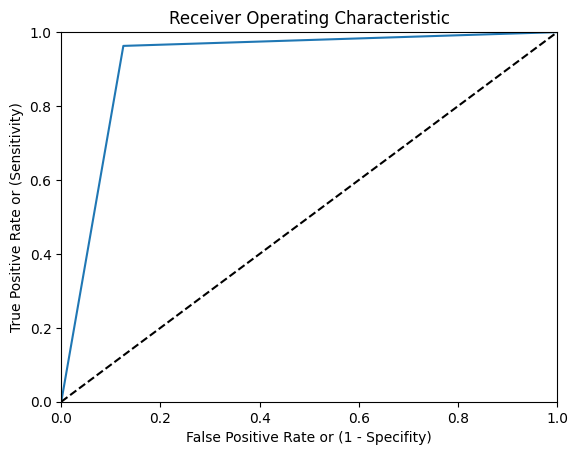

In [19]:
print("Back translate loss:", bt_loss)
evaluate_on_testing_set(bt_test_labels, bt_preds)

Paraphrase 1 loss: 19.84287942154333
AUC is:  0.9046150771030287
              precision    recall  f1-score   support

           0       0.99      0.84      0.91       839
           1       0.54      0.97      0.69       161

    accuracy                           0.86      1000
   macro avg       0.77      0.90      0.80      1000
weighted avg       0.92      0.86      0.88      1000

Confusion Matrix: 
 [[705 134]
 [  5 156]]


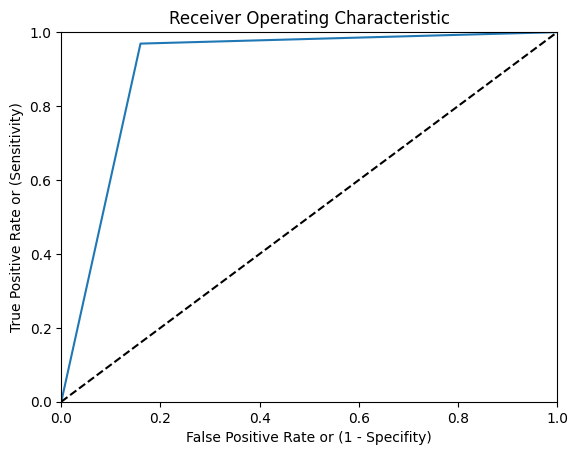

In [20]:
print("Paraphrase 1 loss:", para1_loss)
evaluate_on_testing_set(para1_test_labels, para1_preds)

Paraphrase 2 loss: 17.974622458219528
AUC is:  0.9075948148861037
              precision    recall  f1-score   support

           0       0.99      0.85      0.91       839
           1       0.55      0.97      0.70       161

    accuracy                           0.87      1000
   macro avg       0.77      0.91      0.81      1000
weighted avg       0.92      0.87      0.88      1000

Confusion Matrix: 
 [[710 129]
 [  5 156]]


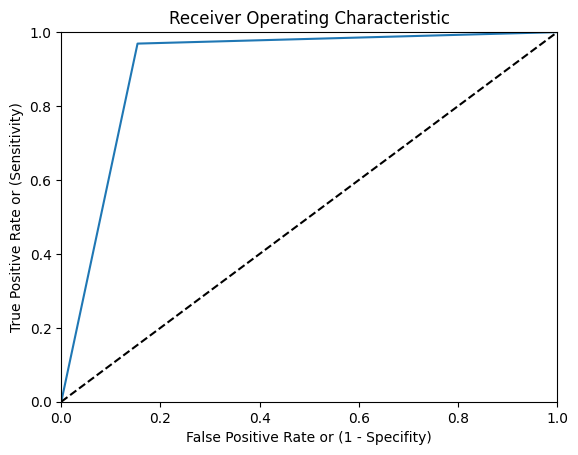

In [21]:
print("Paraphrase 2 loss:", para2_loss)
evaluate_on_testing_set(para2_test_labels, para2_preds)

Noise loss: 28.465850293636322
AUC is:  0.8848562692942649
              precision    recall  f1-score   support

           0       1.00      0.78      0.87       839
           1       0.46      0.99      0.63       161

    accuracy                           0.81      1000
   macro avg       0.73      0.88      0.75      1000
weighted avg       0.91      0.81      0.83      1000

Confusion Matrix: 
 [[651 188]
 [  1 160]]


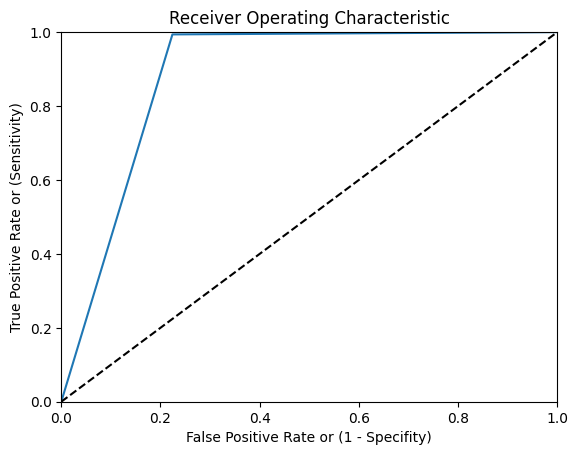

In [22]:
print("Noise loss:", noise_loss)
evaluate_on_testing_set(noise_test_labels, noise_preds)

Style loss: 36.991253197193146
AUC is:  0.8141235869380141
              precision    recall  f1-score   support

           0       0.98      0.68      0.81       839
           1       0.36      0.94      0.53       161

    accuracy                           0.73      1000
   macro avg       0.67      0.81      0.67      1000
weighted avg       0.88      0.73      0.76      1000

Confusion Matrix: 
 [[574 265]
 [  9 152]]


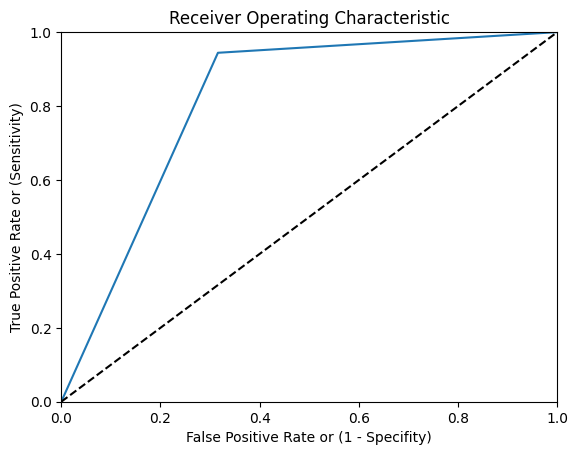

In [38]:
print("Style loss:", style_loss)
evaluate_on_testing_set(style_test_labels, style_preds)

## Summary

|  | f1-score for 0 | f1-score for 1 | Accuracy | 
| --- | --- | --- | --- |
| Original | 1.0 | 0.98 | 0.99 |
| Back translation | 0.93 | 0.74 | 0.89 |
| Paraphrase 1 | 0.91 | 0.69 | 0.86 |
| Paraphrase 2 | 0.91 | 0.70 | 0.87 |
| Noise | 0.87 | 0.63 | 0.81 |
| Style transfer | 0.81 | 0.53 | 0.73 |

